Target density: f(x) = 3x^2 on [0, 1]
Proposal density for rejection sampling: g(x) = 1 on [0, 1]
Chosen constant: M = 3
Acceptance rule: accept Y if U <= Y^2
Theoretical mean = 0.7500000000
Theoretical acceptance rate = 0.333333

N         | AR mean      | AR error     | AR time (s)  | AR acc. rate | INV mean     | INV error    | INV time (s)
----------------------------------------------------------------------------------------------------------------------
      100 | 0.7428595313 | 0.0071404687 | 0.00213093 | 0.002000 | 0.6673839494 | 0.0826160506 | 0.00014970
     1000 | 0.7419870538 | 0.0080129462 | 0.00164428 | 0.020000 | 0.7425800959 | 0.0074199041 | 0.00013091
    10000 | 0.7545963019 | 0.0045963019 | 0.00157961 | 0.200000 | 0.7481186103 | 0.0018813897 | 0.00044250
   100000 | 0.7504166799 | 0.0004166799 | 0.00919882 | 0.333333 | 0.7498156223 | 0.0001843777 | 0.00342386


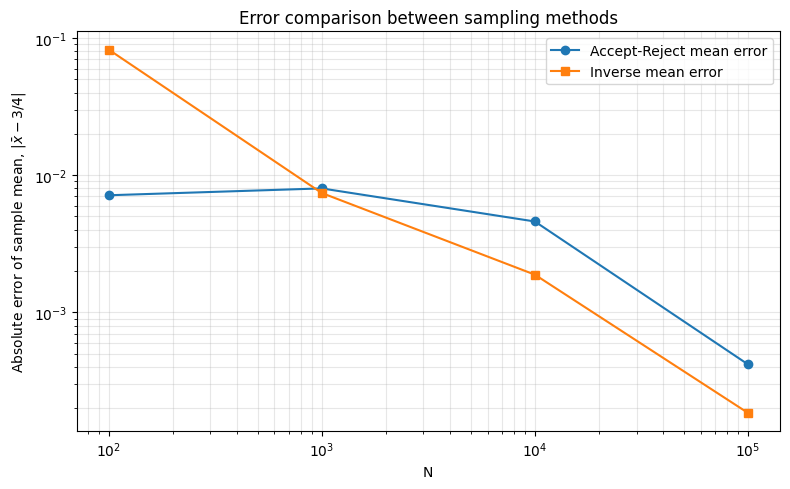

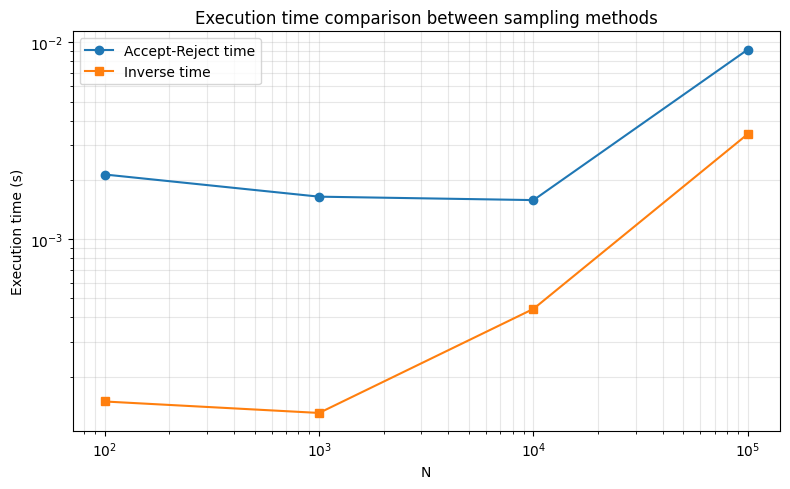

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter


# Define the random seed used to make the simulation reproducible.
SEED = 1000

# Define the sample sizes used in the comparison table.
N_VALUES = np.array([100, 1000, 10000, 100000], dtype=int)

# Define the batch size used in the rejection sampler.
BATCH_SIZE = 50000


def target_pdf(x: np.ndarray) -> np.ndarray:
    """Evaluate the target PDF f(x) = 3 * x^2 on [0, 1].

    Args:
        x: Input points.

    Returns:
        Values of the target PDF at the input points.
    """
    # Return the target density inside the support and zero outside.
    return np.where((0.0 <= x) & (x <= 1.0), 3.0 * x**2, 0.0)


def proposal_pdf(x: np.ndarray) -> np.ndarray:
    """Evaluate the proposal PDF g(x) = 1 on [0, 1].

    Args:
        x: Input points.

    Returns:
        Values of the proposal PDF at the input points.
    """
    # Return the uniform proposal density inside the support and zero outside.
    return np.where((0.0 <= x) & (x <= 1.0), 1.0, 0.0)


def target_cdf(x: np.ndarray) -> np.ndarray:
    """Evaluate the target CDF F(x) = x^3 on [0, 1].

    Args:
        x: Input points.

    Returns:
        Values of the target CDF at the input points.
    """
    # Return the target CDF clipped to the valid support.
    return np.where(x < 0.0, 0.0, np.where(x > 1.0, 1.0, x**3))


def inverse_cdf(u: np.ndarray) -> np.ndarray:
    """Generate samples from the target distribution using the inverse CDF.

    Since F(x) = x^3, solving U = F(x) gives x = U^(1/3).

    Args:
        u: Uniform random samples in [0, 1].

    Returns:
        Samples distributed according to f(x) = 3x^2.
    """
    # Apply the inverse transform formula.
    return u ** (1.0 / 3.0)


def theoretical_mean() -> float:
    """Return the theoretical mean of the target distribution.

    For f(x) = 3x^2 on [0, 1]:
        E[X] = integral_0^1 x * 3x^2 dx = 3/4

    Returns:
        Theoretical mean of the target distribution.
    """
    # Return the analytical mean.
    return 0.75


def theoretical_acceptance_rate() -> float:
    """Return the theoretical acceptance rate of the rejection sampler.

    Here:
        f(x) = 3x^2
        g(x) = 1 on [0, 1]
        M = 3

    Therefore:
        acceptance rate = 1 / M = 1 / 3

    Returns:
        Theoretical acceptance rate.
    """
    # Return the analytical acceptance rate.
    return 1.0 / 3.0


def sample_inverse_method(n: int, seed: int) -> np.ndarray:
    """Generate samples using the inverse transform method.

    Args:
        n: Number of samples to generate.
        seed: Seed for reproducibility.

    Returns:
        Samples distributed according to the target density.
    """
    # Create a reproducible random number generator.
    rng = np.random.default_rng(seed)

    # Generate uniform random samples in [0, 1].
    u = rng.uniform(0.0, 1.0, n)

    # Transform the uniform samples using the inverse CDF.
    x = inverse_cdf(u)

    # Return the generated samples.
    return x


def sample_accept_reject(
    n: int,
    seed: int,
    m: float,
    batch_size: int,
) -> tuple[np.ndarray, int]:
    """Generate samples using the acceptance-rejection method.

    The algorithm is:
        1. Generate Y ~ Uniform(0, 1)
        2. Generate U ~ Uniform(0, 1)
        3. Accept Y if U <= f(Y) / (M * g(Y))

    For this exercise:
        f(y) = 3y^2
        g(y) = 1
        M = 3

    Therefore:
        accept Y if U <= Y^2

    Args:
        n: Number of accepted samples desired.
        seed: Seed for reproducibility.
        m: Constant M such that f(x) <= M g(x).
        batch_size: Number of candidates generated per loop.

    Returns:
        A tuple containing:
            - The accepted samples.
            - The total number of proposal samples generated.
    """
    # Create a reproducible random number generator.
    rng = np.random.default_rng(seed)

    # Create a list to accumulate accepted sample batches.
    accepted_batches = []

    # Initialize the total number of proposals generated.
    total_proposals = 0

    # Initialize the number of accepted samples collected so far.
    total_accepted = 0

    # Keep generating candidates until we collect n accepted samples.
    while total_accepted < n:
        # Generate candidate points from the proposal distribution.
        y = rng.uniform(0.0, 1.0, batch_size)

        # Generate auxiliary uniforms used in the acceptance test.
        u = rng.uniform(0.0, 1.0, batch_size)

        # Compute the acceptance probability f(y) / (M * g(y)).
        acceptance_probability = target_pdf(y) / (m * proposal_pdf(y))

        # Accept candidates whenever u <= acceptance_probability.
        accept_mask = u <= acceptance_probability

        # Extract the accepted candidates from the current batch.
        accepted_y = y[accept_mask]

        # Store the accepted batch.
        accepted_batches.append(accepted_y)

        # Update the number of generated proposals.
        total_proposals += batch_size

        # Update the number of accepted points.
        total_accepted += accepted_y.size

    # Concatenate all accepted batches into a single array.
    accepted_samples = np.concatenate(accepted_batches)

    # Keep exactly n accepted samples.
    accepted_samples = accepted_samples[:n]

    # Return the accepted samples and the proposal count.
    return accepted_samples, total_proposals


def run_comparison_for_n(n: int, seed: int) -> dict:
    """Run both sampling methods for one sample size and collect metrics.

    Args:
        n: Number of target samples.
        seed: Seed used to make the comparison reproducible.

    Returns:
        Dictionary with timing, error, and acceptance metrics.
    """
    # Define the rejection constant M.
    m = 3.0

    # Compute the theoretical mean once for error calculation.
    mean_theoretical = theoretical_mean()

    # Start timing the acceptance-rejection method.
    start_ar = perf_counter()

    # Generate samples using acceptance-rejection.
    samples_ar, total_proposals = sample_accept_reject(
        n=n,
        seed=seed,
        m=m,
        batch_size=BATCH_SIZE,
    )

    # Stop timing the acceptance-rejection method.
    end_ar = perf_counter()

    # Start timing the inverse transform method.
    start_inv = perf_counter()

    # Generate samples using the inverse transform method.
    samples_inv = sample_inverse_method(
        n=n,
        seed=seed,
    )

    # Stop timing the inverse transform method.
    end_inv = perf_counter()

    # Compute the empirical mean of the acceptance-rejection samples.
    mean_ar = np.mean(samples_ar)

    # Compute the empirical mean of the inverse-transform samples.
    mean_inv = np.mean(samples_inv)

    # Compute the absolute error of the sample mean for acceptance-rejection.
    error_ar = abs(mean_ar - mean_theoretical)

    # Compute the absolute error of the sample mean for inverse transform.
    error_inv = abs(mean_inv - mean_theoretical)

    # Compute the empirical acceptance rate.
    acceptance_rate_empirical = n / total_proposals

    # Return all metrics in a dictionary.
    return {
        "n": n,
        "mean_ar": mean_ar,
        "error_ar": error_ar,
        "time_ar": end_ar - start_ar,
        "acceptance_rate_empirical": acceptance_rate_empirical,
        "mean_inv": mean_inv,
        "error_inv": error_inv,
        "time_inv": end_inv - start_inv,
    }


def print_results_table(results: list[dict]) -> None:
    """Print a formatted comparison table for all sample sizes.

    Args:
        results: List of dictionaries returned by run_comparison_for_n().
    """
    # Print the table header.
    print(
        "N         | AR mean      | AR error     | AR time (s)  | AR acc. rate | "
        "INV mean     | INV error    | INV time (s)"
    )
    print("-" * 118)

    # Print one row per sample size.
    for row in results:
        print(
            f"{row['n']:9d} | "
            f"{row['mean_ar']:.10f} | "
            f"{row['error_ar']:.10f} | "
            f"{row['time_ar']:.8f} | "
            f"{row['acceptance_rate_empirical']:.6f} | "
            f"{row['mean_inv']:.10f} | "
            f"{row['error_inv']:.10f} | "
            f"{row['time_inv']:.8f}"
        )


def main() -> None:
    """Run the full comparison for multiple sample sizes."""
    # Compute the theoretical mean of the target distribution.
    mean_theoretical = theoretical_mean()

    # Compute the theoretical acceptance rate.
    acceptance_theoretical = theoretical_acceptance_rate()

    # Print the setup of the problem.
    print("Target density: f(x) = 3x^2 on [0, 1]")
    print("Proposal density for rejection sampling: g(x) = 1 on [0, 1]")
    print("Chosen constant: M = 3")
    print("Acceptance rule: accept Y if U <= Y^2")
    print(f"Theoretical mean = {mean_theoretical:.10f}")
    print(f"Theoretical acceptance rate = {acceptance_theoretical:.6f}")
    print()

    # Create a list to store the results for each sample size.
    results = []

    # Run the comparison for each requested sample size.
    for n in N_VALUES:
        # Use a different seed for each sample size to keep experiments reproducible.
        result = run_comparison_for_n(n=n, seed=SEED + n)

        # Store the result.
        results.append(result)

    # Print the final comparison table.
    print_results_table(results)

    # Extract arrays for plotting.
    n_plot = np.array([row["n"] for row in results], dtype=int)
    error_ar_plot = np.array([row["error_ar"] for row in results], dtype=float)
    error_inv_plot = np.array([row["error_inv"] for row in results], dtype=float)
    time_ar_plot = np.array([row["time_ar"] for row in results], dtype=float)
    time_inv_plot = np.array([row["time_inv"] for row in results], dtype=float)

    # Create the error comparison plot.
    plt.figure(figsize=(8, 5))
    plt.loglog(n_plot, error_ar_plot, marker="o", label="Accept-Reject mean error")
    plt.loglog(n_plot, error_inv_plot, marker="s", label="Inverse mean error")
    plt.xlabel("N")
    plt.ylabel(r"Absolute error of sample mean, $|\bar{x} - 3/4|$")
    plt.title("Error comparison between sampling methods")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Create the execution time comparison plot.
    plt.figure(figsize=(8, 5))
    plt.loglog(n_plot, time_ar_plot, marker="o", label="Accept-Reject time")
    plt.loglog(n_plot, time_inv_plot, marker="s", label="Inverse time")
    plt.xlabel("N")
    plt.ylabel("Execution time (s)")
    plt.title("Execution time comparison between sampling methods")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Show the plots.
    plt.show()


main()